# Pneumonia Detection from Chest X-ray Images --- PyTorch, CNN

## Task Details:
- **Objective**: Build a CNN model to classify chest X-ray images into pneumonia and normal categories.
- **Dataset**: <a href="https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia">Chest X-Ray Images (Pneumonia) dataset from Kaggle</a>

**Disclaimer**: Part of own self-learning. Adapted from <a href="https://medium.com/artificial-corner/chest-x-ray-pneumonia-detection-65315fd4e186">“Chest X-ray Pneumonia Detection” by Golnaz Hosseini (Artificial Corner)</a>.

### Dataset Download

**Disclaimer**: To download the Kaggle dataset, please navigate to your Kaggle account settings, scroll to the "API" section, and click "Create New API Token". This will download a JSON file named *kaggle.json* containing your username and key.

While downloading the dataset in the second cell, you will be prompted to provide your Kaggle username and key. Please manually key in the details, as per what's inside *kaggle.json*.

In [1]:
! pip install opendatasets --quiet

In [2]:
import opendatasets as od

od.download('https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia')

Skipping, found downloaded files in ".\chest-xray-pneumonia" (use force=True to force download)


### Data Preprocessing

Here, after having the data downloaded, we first split the X-ray images into training, validation, and test sets. Then, we define how to load each image—resizing it to a fixed 224×224 size, converting it to a tensor, normalizing pixel values to match what our model expects, and (for training) randomly flipping images to help the model generalize.

**Disclaimer**: Similar to the attached article, author has GPU limitations. We have selected only 1000 images (500 normal & 500 pneumonia) from the dataset for the classification.

In [3]:
# Dataset Preparation
import os, glob

main_dir = 'chest-xray-pneumonia/chest_xray'

num_select = 500
x_nrm = glob.glob(main_dir + '/*/NORMAL/*.jpeg')[:num_select]
x_ph = glob.glob(main_dir + '/*/PNEUMONIA/*.jpeg')[:num_select]
y_nrm = [0] * len(x_nrm)
y_ph = [1] * len(x_ph)

x, y = x_nrm + x_ph, y_nrm + y_ph

In [4]:
# Split into training set, validation set, and test set
# Training set used to train the model, test and validation setsused to evaluate model’s performance
from sklearn.model_selection import train_test_split

x_train, x_test_valid, y_train, y_test_valid = train_test_split(x, 
                                                                y, 
                                                                test_size=0.20,
                                                                shuffle=True,
                                                                random_state=42)

x_test, x_valid, y_test, y_valid = train_test_split(x_test_valid, 
                                                    y_test_valid, 
                                                    test_size=0.5,
                                                    shuffle=True,
                                                    random_state=42
                                                     )

print(f'Train: {len(x_train)}, Valid: {len(x_valid)}, Test: {len(x_test)}')

Train: 800, Valid: 100, Test: 100


In [5]:
# Custom Dataset for loading and resizing images (224x224 - standard pre-trained size)
from PIL import Image
import matplotlib.pyplot as plt
import torch

class CustomDataset():
    def __init__(self, image, lbl, transform=None):
        self.image = image
        self.lbl = lbl
        if transform is not None:
          self.transform = transform
        
    def __len__(self):
        return len(self.image)

    def __getitem__(self, idx):
      image_path = self.image[idx]
      label = self.lbl[idx]

      image = Image.open(image_path).convert('RGB')
      image = image.resize((224,224), resample=Image.BICUBIC)

      if self.transform is not None:
        image = self.transform(image)

      return image, torch.tensor(label, dtype=torch.float32)

In [6]:
# Define data augmentation for the train and test set to increase the size and variability of the training data
import torchvision

train_augment = torchvision.transforms.Compose([
                               torchvision.transforms.RandomHorizontalFlip(),
                               torchvision.transforms.RandomVerticalFlip(),
                               torchvision.transforms.ToTensor()]
                                                )

test_augment = torchvision.transforms.Compose([
                                torchvision.transforms.ToTensor()]
                                              )

Sample index: 763


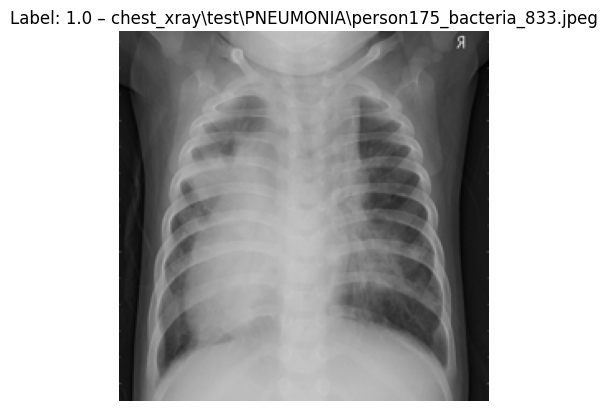

Tensor type: <class 'torch.Tensor'> min/max: 0.003921568859368563 0.8235294222831726 shape: torch.Size([3, 224, 224]) label: 1.0


In [7]:
# Select an image randomly to make sure everything works well
import random
import matplotlib.pyplot as plt

dataset = CustomDataset(x_train, y_train, train_augment)
idx = random.randint(0, len(dataset)-1)
print(f"Sample index: {idx}")

img_tensor, lbl = dataset[idx]

# img_tensor is [3,224,224]: convert for plotting
img_np = img_tensor.permute(1,2,0).numpy()
plt.imshow(img_np)
plt.title(f'Label: {lbl.item()} – {x_train[idx].split("/")[-1]}')
plt.axis('off')
plt.show()

print("Tensor type:", type(img_tensor),
      "min/max:", img_tensor.min().item(), img_tensor.max().item(),
      "shape:", img_tensor.shape,
      "label:", lbl.item())

In [8]:
# DataLoaders for each split
from torch.utils.data import DataLoader

dataset_train = CustomDataset(x_train, y_train, train_augment)
dataset_valid = CustomDataset(x_valid, y_valid, test_augment)
dataset_test = CustomDataset(x_test, y_test, test_augment)

BATCH = 32
train_dataloader = DataLoader(
    dataset_train, batch_size=BATCH, shuffle=True, num_workers=0, 
    )

valid_dataloader = DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0,
    )

test_loader = DataLoader(
    dataset_valid, batch_size=1, shuffle=False, num_workers=0,
    )

dataloaders ={'train': train_dataloader, 'valid': valid_dataloader, 'test':  test_loader}

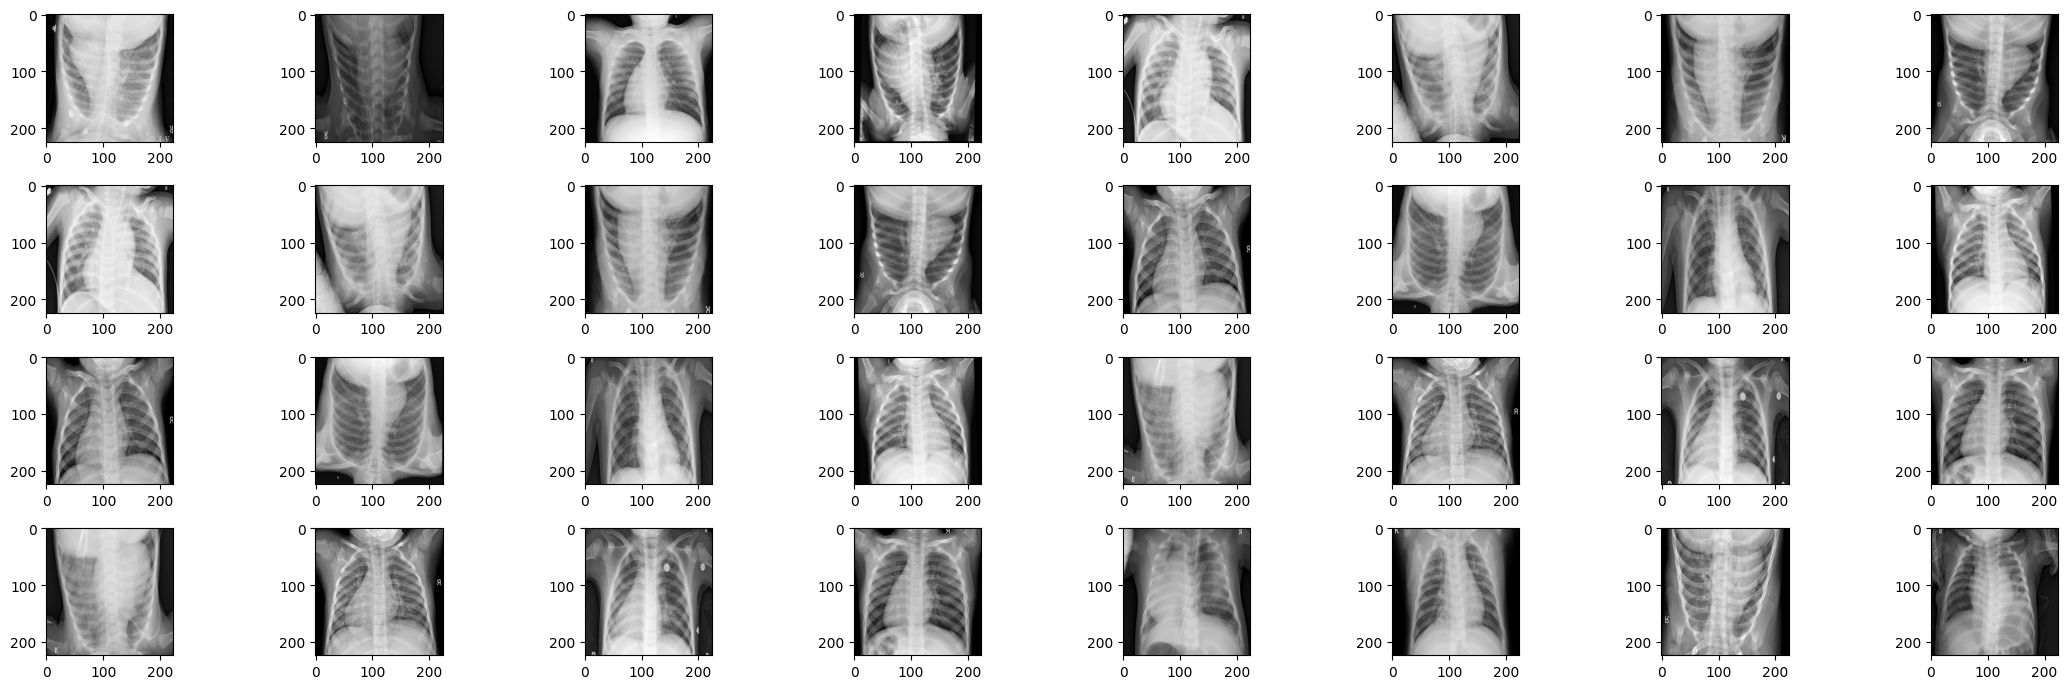

In [9]:
# Check the outputs of the data loader in one batch
train_img, lbl_train = next(iter(dataloaders['train']))

p = 4
fig, ax = plt.subplots(nrows=p, ncols=int(len(train_img)/p), figsize = (22, 7))

for i in range(int(len(train_img)/p)):
    ax[0][i].imshow(train_img[i+p*0][0,:,:], cmap='gray')
    ax[1][i].imshow(train_img[i+p*1][0,:,:], cmap='gray')
    ax[2][i].imshow(train_img[i+p*2][0,:,:], cmap='gray')
    ax[3][i].imshow(train_img[i+p*3][0,:,:], cmap='gray')
plt.tight_layout()

### CNN model architecture

Next, we build a classifier by taking a DenseNet121 model pre-trained on ImageNet, freezing its feature-extracting layers, and swapping in a new final layer that outputs one number (logit) for “pneumonia” vs “normal.”

In [10]:
import torch.nn as nn
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [11]:
# CNN model class and count trainable params
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = torchvision.models.densenet121(pretrained=True)
        # freeze all parameters manually
        for p in self.model.parameters():
            p.requires_grad = False
        num_ftrs = self.model.classifier.in_features
        self.model.classifier = nn.Linear(num_ftrs, 1)

    def forward(self, x):
        x = self.model(x)
        return x

model_name = 'DenseNet121'
model = CNNModel().to(device)

def count_parameters(model):
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return params/1000000

print("Trained Parameters:", count_parameters(model))

C:\Users\tanhu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\tanhu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Trained Parameters: 0.001025


In [12]:
# Define loss function, optimizer, and hyperparameters
# Stochastic Gradient Descent(SGD) as our optimizer with a learning rate of 0.01 and Binary cross entropy with logit loss as our loss function
num_epochs = 30
learning_rate = 0.01
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [13]:
!pip install torchmetrics --quiet

In [14]:
# Training the model
# Passing batches of images through the model, computing the loss, and updating the model parameters using backpropagation
import torchmetrics

def train_one_epoch(model, criterion, optimizer):
  model.train()
  train_loss = 0
  acc_train = torchmetrics.Accuracy('binary').to(device)
  for i, (inputs, targets) in enumerate(dataloaders['train']):

      inputs = inputs.to(device)
      targets = targets.to(device)
  
      outputs = model(inputs)
      outputs = torch.squeeze(outputs, 1)
      loss = criterion(outputs, targets)
  
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
  
      train_loss += loss.item()
      acc_train(outputs, targets.int())
  return model, train_loss/len(dataloaders['train']), acc_train.compute().item()

In [15]:
# Evaluate the model on the validation set
def evaluate(model, criterion):
  model.eval()
  with torch.no_grad():
    val_loss = 0
    acc_valid = torchmetrics.Accuracy('binary').to(device)
    for i, (inputs, targets) in enumerate(dataloaders['valid']):
      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)
      outputs = torch.squeeze(outputs, 1)
      loss = criterion(outputs, targets)

      val_loss += loss.item()
      acc_valid(outputs, targets.int())

  return val_loss / len(dataloaders['valid']), acc_valid.compute()

In [16]:
# Training loop
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

for epoch in range(num_epochs):
  print(f'Epoch {epoch+1}/{num_epochs}')
  model, loss_train, acc_train = train_one_epoch(model,
                                                criterion,
                                                optimizer
                                                )

  loss_valid, acc_valid = evaluate(model,
                                   criterion)

  acc_valid = acc_valid.cpu().numpy()

  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)

  acc_train_hist.append(acc_train)
  acc_valid_hist.append(acc_valid)

  print(f'train: loss {loss_train:.2}, accuracy {acc_train:.2} | valid: loss {loss_valid:.2}, accuracy {acc_valid:.2}')
  print('-----------------------------------------------------------------------------')
  print()

print("Epochs finished.")

Epoch 1/30
train: loss 0.6, accuracy 0.7 | valid: loss 0.49, accuracy 0.74
-----------------------------------------------------------------------------

Epoch 2/30
train: loss 0.44, accuracy 0.86 | valid: loss 0.44, accuracy 0.73
-----------------------------------------------------------------------------

Epoch 3/30
train: loss 0.37, accuracy 0.89 | valid: loss 0.3, accuracy 0.9
-----------------------------------------------------------------------------

Epoch 4/30
train: loss 0.35, accuracy 0.89 | valid: loss 0.27, accuracy 0.92
-----------------------------------------------------------------------------

Epoch 5/30
train: loss 0.31, accuracy 0.91 | valid: loss 0.32, accuracy 0.84
-----------------------------------------------------------------------------

Epoch 6/30
train: loss 0.28, accuracy 0.91 | valid: loss 0.25, accuracy 0.92
-----------------------------------------------------------------------------

Epoch 7/30
train: loss 0.27, accuracy 0.93 | valid: loss 0.27, accur

### Evaluation

Here, we evaluate our model. We first take our trained model and run it on the held-out test images. Then, we compute 4 metrics --- accuracy, precision, recall and F1—score and also show a confusion matrix to see how many images were correctly or incorrectly labeled.

In [17]:
# Held-out test set evaluation
targets = []
predictions = []

with torch.no_grad():
    model.eval()
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        targets.append(labels.cpu().numpy())
        preds = torch.round(torch.sigmoid(outputs.data))
        predictions.append(preds.item())

In [18]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(
    targets,
    predictions,
    target_names=['Normal','Pneumonia'],
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()


report_df[['precision','recall','f1-score']] = report_df[['precision','recall','f1-score']].applymap(lambda x: f"{x:.2f}")
report_df['support'] = report_df['support'].astype(int)

display(report_df)

C:\Users\tanhu\AppData\Local\Temp\ipykernel_51320\3545821333.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  report_df[['precision','recall','f1-score']] = report_df[['precision','recall','f1-score']].applymap(lambda x: f"{x:.2f}")


,precision,recall,f1-score,support
Normal,0.95,0.98,0.96,54
Pneumonia,0.98,0.93,0.96,46
accuracy,0.96,0.96,0.96,0
macro avg,0.96,0.96,0.96,100
weighted avg,0.96,0.96,0.96,100


### Visualizations

Here, we plot the training/validation loss plot and accuracy plot.

What we want is:
- Monotonic downward trends in both train and val loss for loss plot.
- Monotonic upward trends in both train and val accuracy for accuracy plot.
- Minimal gap between training and validation curves to show least signs of overfitting.

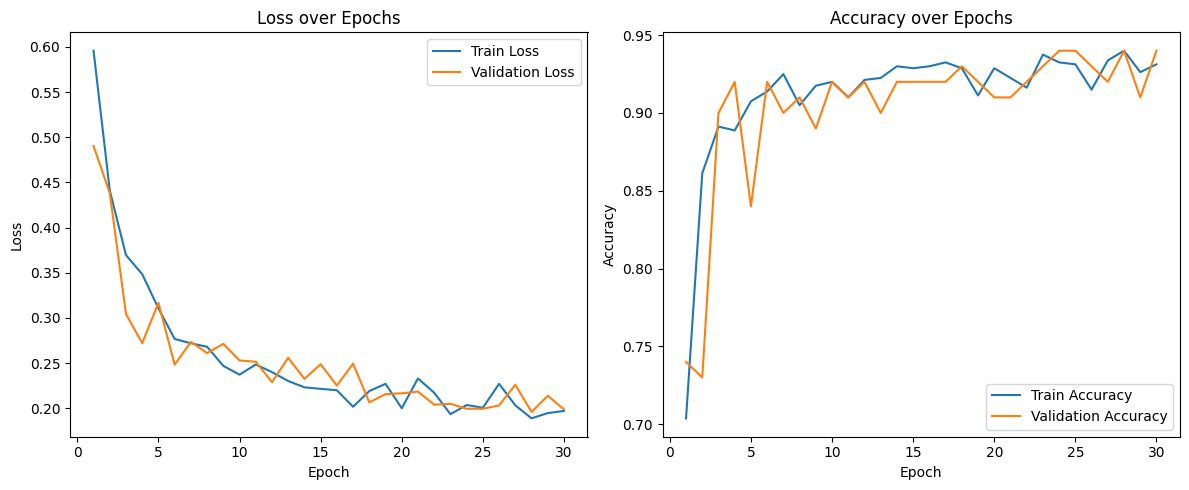

In [19]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_train_hist, label='Train Loss')
plt.plot(epochs, loss_valid_hist, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, acc_train_hist, label='Train Accuracy')
plt.plot(epochs, acc_valid_hist, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

We can also use the Receiver Operating Characteristic (ROC) curve to visualise the true positive rate (TPR) against the false positive rate (FPR) for a range of thresholds.

The TPR is the percentage of positive examples that were correctly classified as positive. The FPR is the percentage of negative examples that were incorrectly classified as positive.

A good ROC curve will have a high TPR and a low FPR. This means that the model is good at identifying positive examples and not identifying negative examples as positive.

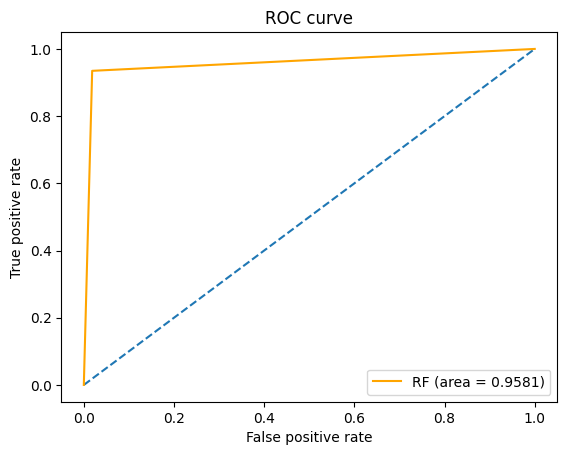

In [20]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(targets, predictions, pos_label=1)
auc = auc(fpr, tpr)

plt.figure()
plt.plot([0, 1], [0, 1],"--")

plt.plot(fpr, tpr, label='RF (area = {:.4f})'.format(auc), color='orange')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()